Step 1 — Mount Drive & load the pre-SMOTE file

In [1]:
#  Mount Drive and load pre-SMOTE preprocessed dataset
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np

# Update this path only if your file is in a different folder
preproc_path = '/content/drive/MyDrive/ColabData/FYDP/final_ml.csv'

# Load
df = pd.read_csv(preproc_path)

# Quick checks
print("Loaded file:", preproc_path)
print("Shape:", df.shape)
print("Columns (count):", len(df.columns))
print("Missing values total:", df.isnull().sum().sum())
print("\nClass distribution:\n", df['class'].value_counts())
display(df.head())


Mounted at /content/drive
Loaded file: /content/drive/MyDrive/ColabData/FYDP/final_ml.csv
Shape: (42264, 38)
Columns (count): 38
Missing values total: 0

Class distribution:
 class
Replay       12007
DoS          11672
Benign        9427
Evil Twin     5684
FDI           3474
Name: count, dtype: int64


,timestamp_c,frame.number_x,frame.len_x,frame.protocols_x,wlan.duration_x,wlan.ra_x,wlan.ta_x,wlan.da_x,wlan.sa_x,wlan.bssid_x,...,tcp.options_x,udp.srcport_x,udp.dstport_x,udp.length_x,data.data_x,data.len_x,wlan.fc.type_x,wlan.fc.subtype_x,time_since_last_packet_x,class
0,28105.97520,60.0,24.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,2.0,4.0,0.000000,Benign
1,28105.97550,61.0,24.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,2.0,4.0,0.000298,Benign
2,28107.09931,75.0,104.0,0.0,0.0,4.0,1.0,4.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0,1.123815,Benign
3,28114.78570,122.0,86.0,2.0,44.0,1.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,2.0,8.0,7.686387,Benign
4,28114.88188,124.0,26.0,0.0,60.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,2.0,12.0,0.096183,Benign


Step 2 — Drop Identifier & Non-Predictive Columns

In [2]:
#  Drop identifier and non-informative columns
drop_cols = [
    'ip.src_x', 'ip.dst_x', 'wlan.ra_x', 'wlan.ta_x', 'wlan.da_x',
    'wlan.sa_x', 'wlan.bssid_x', 'ip.id_x', 'tcp.seq_raw_x',
    'tcp.ack_raw_x', 'tcp.options_x', 'data.data_x'
]

# Drop only if they exist
drop_cols = [c for c in drop_cols if c in df.columns]
df = df.drop(columns=drop_cols)

print("✅ Dropped columns:", drop_cols)
print("New shape:", df.shape)


✅ Dropped columns: ['ip.src_x', 'ip.dst_x', 'wlan.ra_x', 'wlan.ta_x', 'wlan.da_x', 'wlan.sa_x', 'wlan.bssid_x', 'ip.id_x', 'tcp.seq_raw_x', 'tcp.ack_raw_x', 'tcp.options_x', 'data.data_x']
New shape: (42264, 26)


Step 3 — Label Encoding & Train–Test Split (70 : 30)

In [3]:
#  Encode target and split (70:30)
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Encode the target column
le = LabelEncoder()
df['class_enc'] = le.fit_transform(df['class'])
label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Label encoding mapping:", label_mapping)

# Separate features and target
X = df.drop(columns=['class', 'class_enc'])
y = df['class_enc']

# Stratified split 70:30
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("\n✅ Dataset split completed (70:30 ratio)")
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)
print("\nClass distribution in training set:")
print(y_train.value_counts())
print("\nClass distribution in testing set:")
print(y_test.value_counts())


Label encoding mapping: {'Benign': np.int64(0), 'DoS': np.int64(1), 'Evil Twin': np.int64(2), 'FDI': np.int64(3), 'Replay': np.int64(4)}

✅ Dataset split completed (70:30 ratio)
Training set shape: (29584, 25)
Testing set shape: (12680, 25)

Class distribution in training set:
class_enc
4    8404
1    8170
0    6599
2    3979
3    2432
Name: count, dtype: int64

Class distribution in testing set:
class_enc
4    3603
1    3502
0    2828
2    1705
3    1042
Name: count, dtype: int64


Step 4 — Select Numeric Features & Scale (fit only on training data)

In [4]:
#  Select numeric columns and scale (fit only on training data)
from sklearn.preprocessing import StandardScaler
import numpy as np

# Select numeric columns
X_train_num = X_train.select_dtypes(include=[np.number]).copy()
X_test_num  = X_test.select_dtypes(include=[np.number]).copy()

# Initialize scaler
scaler = StandardScaler()

# Fit on training only, transform both
X_train_scaled = scaler.fit_transform(X_train_num)
X_test_scaled  = scaler.transform(X_test_num)

# Keep feature names for later use
feature_names = X_train_num.columns.tolist()

print("✅ Scaling complete!")
print("Number of numeric features:", len(feature_names))
print("Training set shape after scaling:", X_train_scaled.shape)
print("Testing set shape after scaling:", X_test_scaled.shape)


✅ Scaling complete!
Number of numeric features: 25
Training set shape after scaling: (29584, 25)
Testing set shape after scaling: (12680, 25)


Step 5 — Initial Random Forest for Feature Importance

In [5]:
#  Train initial Random Forest to get feature importances
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

# Initial Random Forest (no SMOTE, balanced weights)
rf_init = RandomForestClassifier(
    n_estimators=50,
    random_state=12,
    n_jobs=-1,
    class_weight='balanced'   # helps deal with imbalance during importance estimation
)
rf_init.fit(X_train_scaled, y_train)

# Get feature importances
importances = rf_init.feature_importances_
feat_imp_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feat_imp_df = feat_imp_df.sort_values('importance', ascending=False).reset_index(drop=True)

print("✅ Initial Random Forest trained for feature importance")
print("\nTop 15 features by importance:\n")
print(feat_imp_df.head(15))


✅ Initial Random Forest trained for feature importance

Top 15 features by importance:

                     feature  importance
0                timestamp_c    0.418270
1            wlan.duration_x    0.084005
2               ip.hdr_len_x    0.078180
3              udp.dstport_x    0.063120
4                   ip.len_x    0.061261
5             frame.number_x    0.039769
6                frame.len_x    0.032791
7              tcp.dstport_x    0.031077
8          tcp.window_size_x    0.030798
9             wlan.fc.type_x    0.030403
10  time_since_last_packet_x    0.025811
11             tcp.srcport_x    0.024060
12                wlan.seq_x    0.022262
13             udp.srcport_x    0.015402
14               wlan.frag_x    0.014341


Step 6 — Select top features (reduce dimensionality)

In [6]:
#  Select top-k features based on importance
top_k = 15  # you can later try 10 or 12 to test performance vs overfitting
top_features = feat_imp_df['feature'].tolist()[:top_k]
print("✅ Selected top features (k={}):".format(top_k))
print(top_features)

# Reduce training and testing sets to only these top features
import pandas as pd
X_train_sel = pd.DataFrame(X_train_scaled, columns=feature_names)[top_features].values
X_test_sel  = pd.DataFrame(X_test_scaled,  columns=feature_names)[top_features].values

print("\nShapes after selection ->")
print("X_train_sel:", X_train_sel.shape)
print("X_test_sel :", X_test_sel.shape)


✅ Selected top features (k=15):
['timestamp_c', 'wlan.duration_x', 'ip.hdr_len_x', 'udp.dstport_x', 'ip.len_x', 'frame.number_x', 'frame.len_x', 'tcp.dstport_x', 'tcp.window_size_x', 'wlan.fc.type_x', 'time_since_last_packet_x', 'tcp.srcport_x', 'wlan.seq_x', 'udp.srcport_x', 'wlan.frag_x']

Shapes after selection ->
X_train_sel: (29584, 15)
X_test_sel : (12680, 15)


Step7- Correct Partial SMOTE for Multi-class

In [7]:
#  Partial SMOTE with valid oversampling only
from imblearn.over_sampling import SMOTE
from collections import Counter

print("Before SMOTE:", Counter(y_train))

max_class = max(Counter(y_train).values())
target = int(0.8 * max_class)

# Only oversample classes that have fewer samples than the target
sampling_strategy = {
    cls: target for cls, count in Counter(y_train).items() if count < target
}

sm = SMOTE(sampling_strategy=sampling_strategy, random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_sel, y_train)

print("\n✅ Partial SMOTE applied successfully")
print("After SMOTE :", Counter(y_train_res))
print("Shapes -> X_train_res:", X_train_res.shape, " | y_train_res:", y_train_res.shape)


Before SMOTE: Counter({4: 8404, 1: 8170, 0: 6599, 2: 3979, 3: 2432})

✅ Partial SMOTE applied successfully
After SMOTE : Counter({4: 8404, 1: 8170, 2: 6723, 0: 6723, 3: 6723})
Shapes -> X_train_res: (36743, 15)  | y_train_res: (36743,)


Step 8 — Regularized Random Forest + Cross-Validation

In [8]:
#  Regularized Random Forest with cross-validation
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier

# Define parameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],       # None = full depth; others regularize
    'min_samples_leaf': [1, 2, 5]      # larger = smoother, less overfit
}

# 5-fold stratified CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Base model
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

# Grid search
grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring='f1_macro',    # balanced metric for multi-class
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train_res, y_train_res)

print("✅ Grid search completed.")
print("Best Parameters:", grid.best_params_)
print("Best Cross-Validation F1 Score:", round(grid.best_score_, 4))

# Save the best model
best_rf = grid.best_estimator_


Fitting 5 folds for each of 18 candidates, totalling 90 fits
✅ Grid search completed.
Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 200}
Best Cross-Validation F1 Score: 0.9949


Step 9 —Final Evaluation on Test Set

✅ Final Test Accuracy: 0.9927

Classification Report:
               precision    recall  f1-score   support

           0     0.9933    0.9996    0.9965      2828
           1     0.9883    0.9914    0.9899      3502
           2     1.0000    0.9994    0.9997      1705
           3     0.9990    0.9990    0.9990      1042
           4     0.9910    0.9833    0.9872      3603

    accuracy                         0.9927     12680
   macro avg     0.9943    0.9946    0.9945     12680
weighted avg     0.9927    0.9927    0.9927     12680



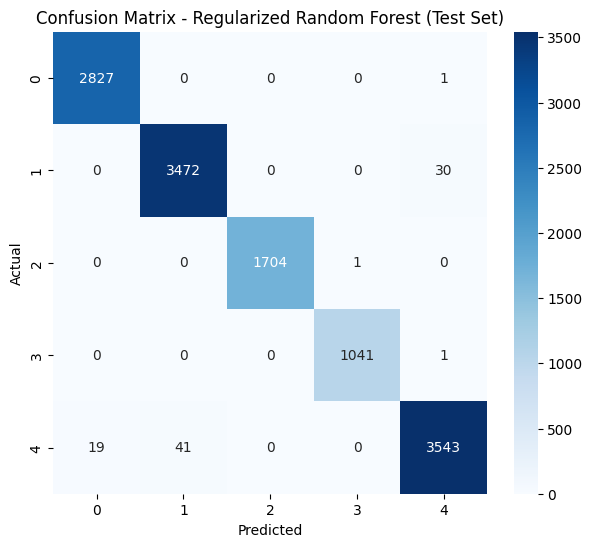

In [9]:
#  Evaluate tuned Random Forest on the untouched test set
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Predict on test set
y_pred_test = best_rf.predict(X_test_sel)

# Calculate metrics
test_acc = accuracy_score(y_test, y_pred_test)
print("✅ Final Test Accuracy:", round(test_acc, 4))
print("\nClassification Report:\n", classification_report(y_test, y_pred_test, digits=4))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Regularized Random Forest (Test Set)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


Step 10 — Save the Model

In [10]:
# Cell 10: Save the final regularized Random Forest model
import joblib

model_path = '/content/drive/MyDrive/ColabData/FYDP/random_forest_ids_model_regularized.joblib'
joblib.dump(best_rf, model_path)

print("✅ Final model saved successfully at:", model_path)


✅ Final model saved successfully at: /content/drive/MyDrive/ColabData/FYDP/random_forest_ids_model_regularized.joblib


Step11- Save the dataset

In [11]:
# ✅ Save the final feature-engineered dataset (ready for any ML model)
import pandas as pd

# Combine the selected, scaled features and the encoded labels
df_final = pd.DataFrame(X_train_res, columns=top_features)
df_final['class'] = y_train_res.values  # add target column back

# Save to Google Drive
final_dataset_path = '/content/drive/MyDrive/ColabData/FYDP/final_ml_feature_engineered_regularized.csv'
df_final.to_csv(final_dataset_path, index=False)

print("✅ Final feature-engineered dataset saved at:")
print(final_dataset_path)
print("Shape:", df_final.shape)


✅ Final feature-engineered dataset saved at:
/content/drive/MyDrive/ColabData/FYDP/final_ml_feature_engineered_regularized.csv
Shape: (36743, 16)


In [12]:

# Compute ToList Importance Scores (Random Forest)

import numpy as np
import pandas as pd

# Top-15 ToList selected features
top_features = [
    'timestamp_c', 'wlan.duration_x', 'ip.len_x', 'udp.dstport_x',
    'ip.hdr_len_x', 'udp.srcport_x', 'frame.len_x', 'tcp.dstport_x',
    'frame.number_x', 'wlan.seq_x', 'wlan.fc.type_x',
    'time_since_last_packet_x', 'tcp.srcport_x',
    'wlan.fc.subtype_x', 'data.len_x'
]

# Full feature names used during RF training
all_features = X_train.columns.tolist()

# Get RF feature importances
rf_importances = rf_init.feature_importances_


# Create DataFrame
importance_df = pd.DataFrame({
    "Feature": all_features,
    "Importance": rf_importances
})

# Extract Top-15 ToList importance scores
tolist_df = importance_df[importance_df["Feature"].isin(top_features)]

# Sort descending
tolist_df = tolist_df.sort_values("Importance", ascending=False)

tolist_df


,Feature,Importance
0,timestamp_c,0.418270
4,wlan.duration_x,0.084005
8,ip.hdr_len_x,0.078180
19,udp.dstport_x,0.063120
9,ip.len_x,0.061261
1,frame.number_x,0.039769
2,frame.len_x,0.032791
14,tcp.dstport_x,0.031077
22,wlan.fc.type_x,0.030403
24,time_since_last_packet_x,0.025811


In [13]:

# Class-wise ToList Feature Importance using One-vs-Rest RF

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import label_binarize

# Top-15 ToList features (FIXED)
top_features = [
    'timestamp_c', 'wlan.duration_x', 'ip.len_x', 'udp.dstport_x',
    'ip.hdr_len_x', 'udp.srcport_x', 'frame.len_x', 'tcp.dstport_x',
    'frame.number_x', 'wlan.seq_x', 'wlan.fc.type_x',
    'time_since_last_packet_x', 'tcp.srcport_x',
    'wlan.fc.subtype_x', 'data.len_x'
]

# Prepare data
X_train_tolist = pd.DataFrame(X_train_scaled, columns=X_train.columns)[top_features]
y_train_arr = y_train.values

classes = np.unique(y_train_arr)
n_classes = len(classes)

# Store importances
class_importances = []

print("🔹 Training One-vs-Rest Random Forests for ToList...")

for cls in classes:
    print(f"  → Class {cls}")

    # Binary labels
    y_binary = (y_train_arr == cls).astype(int)

    rf_ovr = RandomForestClassifier(
        n_estimators=100,
        max_depth=42,
        random_state=42,
        n_jobs=-1,
        class_weight='balanced'
    )

    rf_ovr.fit(X_train_tolist, y_binary)
    class_importances.append(rf_ovr.feature_importances_)

# Convert to array → shape (n_classes, n_features)
class_importances = np.array(class_importances)

print("✅ Class-wise ToList importance computed")


🔹 Training One-vs-Rest Random Forests for ToList...
  → Class 0
  → Class 1
  → Class 2
  → Class 3
  → Class 4
✅ Class-wise ToList importance computed


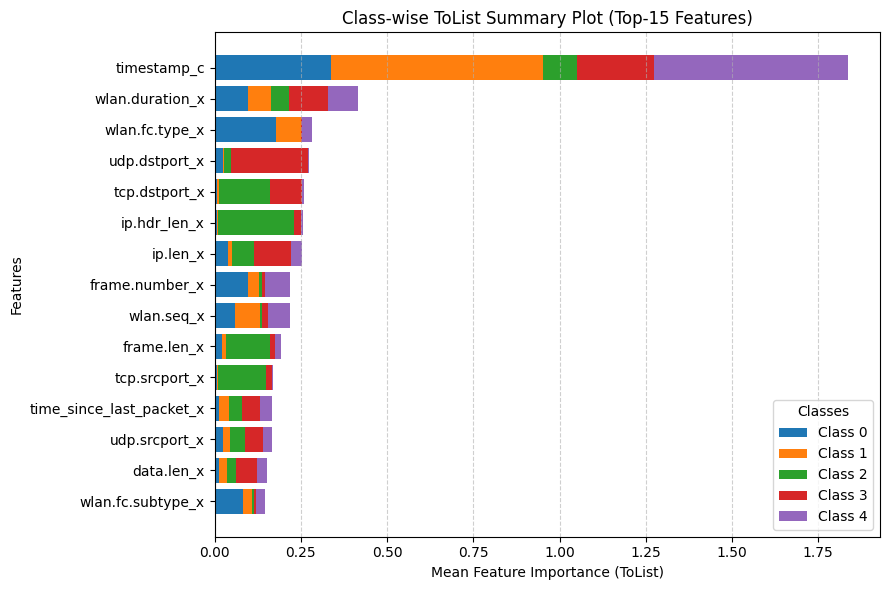

In [14]:

# Class-wise ToList Summary Plot (Stacked Bar)

import matplotlib.pyplot as plt

# Mean importance per feature (for sorting)
mean_importance = class_importances.mean(axis=0)
sorted_idx = np.argsort(mean_importance)

# Sort features and importances
features_sorted = np.array(top_features)[sorted_idx]
importances_sorted = class_importances[:, sorted_idx]

# Plot
plt.figure(figsize=(9, 6))

left = np.zeros(len(features_sorted))

colors = plt.cm.tab10.colors  # consistent class colors

for i, cls in enumerate(classes):
    plt.barh(
        features_sorted,
        importances_sorted[i],
        left=left,
        color=colors[i % len(colors)],
        label=f"Class {cls}"
    )
    left += importances_sorted[i]

plt.xlabel("Mean Feature Importance (ToList)")
plt.ylabel("Features")
plt.title("Class-wise ToList Summary Plot (Top-15 Features)")
plt.legend(title="Classes", loc="lower right")
plt.grid(axis="x", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


In [16]:
#  Lightweight IDS Check — Random Forest
import time, os, joblib, tracemalloc
import pandas as pd

model = best_rf

# 1. Model Size
joblib.dump(model, "_tmp.joblib")
model_size_mb = os.path.getsize("_tmp.joblib") / (1024 ** 2)
os.remove("_tmp.joblib")

# 2. Inference Latency (batch → ms/sample)
t0 = time.perf_counter()
_ = model.predict(X_test_sel)
latency_ms = (time.perf_counter() - t0) / X_test_sel.shape[0] * 1000

# 3. Throughput
throughput = X_test_sel.shape[0] / (latency_ms / 1000 * X_test_sel.shape[0])

# 4. Peak RAM during inference
tracemalloc.start()
_ = model.predict(X_test_sel)
_, peak_bytes = tracemalloc.get_traced_memory()
tracemalloc.stop()
peak_ram_mb = peak_bytes / (1024 ** 2)

# ── Results & Threshold Check ─────────────
metrics = [
    ("Model Size",         model_size_mb,  50.0,   "MB",  False, "≤ 50 MB"),
    ("Inference Latency",  latency_ms,      5.0,   "ms",  False, "≤ 5 ms/sample"),
    ("Throughput",         throughput,   1000.0,  "s/s",  True,  "≥ 1000 samples/sec"),
    ("Peak RAM",           peak_ram_mb,   200.0,   "MB",  False, "≤ 200 MB"),
]

rows = []
for name, val, limit, unit, higher_ok, label in metrics:
    passed = val >= limit if higher_ok else val <= limit
    rows.append({
        "Metric"    : name,
        "Value"     : f"{val:.2f} {unit}",
        "Threshold" : label,
        "Status"    : "✅ PASS" if passed else "❌ FAIL"
    })

df = pd.DataFrame(rows)
print(df.to_string(index=False))

passed_all = all("PASS" in r["Status"] for r in rows)
print("\n✅ Model is LIGHTWEIGHT." if passed_all else "\n⚠️  Model does NOT fully meet lightweight criteria.")

           Metric        Value          Threshold Status
       Model Size     21.35 MB            ≤ 50 MB ✅ PASS
Inference Latency      0.09 ms      ≤ 5 ms/sample ✅ PASS
       Throughput 10709.86 s/s ≥ 1000 samples/sec ✅ PASS
         Peak RAM      2.98 MB           ≤ 200 MB ✅ PASS

✅ Model is LIGHTWEIGHT.
